In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from function.library import *
from pygam import LogisticGAM

In [2]:
print(np.__version__)

2.4.6


In [3]:
X_train = pd.read_csv('../data/X_train.csv')   
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

In [ ]:

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = pd.Series(y_train).reset_index(drop=True)
y_test = pd.Series(y_test).reset_index(drop=True)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (759384, 23)
X_test shape: (118799, 23)
y_train shape: (759384,)
y_test shape: (118799,)


In [5]:
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=100000,
    stratify=y_train,
    random_state=42
)

X_tune = X_tune.reset_index(drop=True)
y_tune = pd.Series(y_tune).reset_index(drop=True)

print("Tuning Shape:", X_tune.shape)
print("Tuning Distribution:")
print(pd.Series(y_tune).value_counts())

Tuning Shape: (100000, 23)
Tuning Distribution:
1.0    50000
0.0    50000
Name: count, dtype: int64


In [ ]:

level1_lam_values = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]

level1_n_splines_values = [
    10,
    15
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Number of folds:", cv.get_n_splits())
print("Level 1 lambda values:", level1_lam_values)
print("Level 1 n_splines values:", level1_n_splines_values)

Number of folds: 5
Level 1 lambda values: [0.001, 0.01, 0.1, 1, 10, 100]
Level 1 n_splines values: [10, 15]


In [ ]:

level1_results = []

best_score_level1 = -np.inf
best_lam_level1 = None
best_n_splines_level1 = None

for n_splines in level1_n_splines_values:

    for lam in level1_lam_values:

        fold_auc_scores = []
        combination_valid = True

        print("\n" + "=" * 70)
        print(
            f"Testing Level 1: "
            f"n_splines={n_splines}, lambda={lam}"
        )

        for fold, (train_idx, val_idx) in enumerate(
            cv.split(X_tune, y_tune),
            start=1
        ):

            X_train_fold = X_tune.iloc[train_idx]
            X_val_fold = X_tune.iloc[val_idx]

            y_train_fold = y_tune.iloc[train_idx]
            y_val_fold = y_tune.iloc[val_idx]

            try:

                gam = LogisticGAM(
                    lam=lam,
                    n_splines=n_splines,
                    max_iter=1000,
                    tol=1e-4,
                    verbose=False
                )

                gam.fit(
                    X_train_fold.values,
                    y_train_fold.values
                )

                if not gam.statistics_.get(
                    "pseudo_r2",
                    {}
                ):
                    print(
                        f"Rejected at Fold {fold}: "
                        "invalid model statistics."
                    )
                    combination_valid = False
                    break

                y_val_prob = gam.predict_proba(
                    X_val_fold.values
                )

                if (
                    np.any(~np.isfinite(y_val_prob))
                    or np.any(y_val_prob < 0)
                    or np.any(y_val_prob > 1)
                ):
                    print(
                        f"Rejected at Fold {fold}: "
                        "invalid predicted probabilities."
                    )
                    combination_valid = False
                    break

                fold_auc = roc_auc_score(
                    y_val_fold,
                    y_val_prob
                )

                fold_auc_scores.append(fold_auc)

                print(
                    f"Fold {fold} ROC-AUC: "
                    f"{fold_auc:.6f}"
                )

            except Exception as error:

                print(
                    f"Rejected at Fold {fold}: "
                    f"{type(error).__name__}: {error}"
                )

                combination_valid = False
                break

        if combination_valid and len(fold_auc_scores) == 5:

            mean_auc = np.mean(fold_auc_scores)
            std_auc = np.std(
                fold_auc_scores,
                ddof=1
            )

            level1_results.append({
                "Search Level": "Level 1",
                "Lambda": lam,
                "n_splines": n_splines,
                "Mean ROC-AUC": mean_auc,
                "Std ROC-AUC": std_auc,
                "Valid Folds": len(fold_auc_scores),
                "Status": "Accepted"
            })

            print(
                f"\nn_splines={n_splines}, "
                f"lambda={lam} | "
                f"Mean ROC-AUC={mean_auc:.6f} | "
                f"Std={std_auc:.6f}"
            )

            if mean_auc > best_score_level1:

                best_score_level1 = mean_auc
                best_lam_level1 = lam
                best_n_splines_level1 = n_splines

        else:

            level1_results.append({
                "Search Level": "Level 1",
                "Lambda": lam,
                "n_splines": n_splines,
                "Mean ROC-AUC": np.nan,
                "Std ROC-AUC": np.nan,
                "Valid Folds": len(fold_auc_scores),
                "Status": "Rejected"
            })


level1_results_df = pd.DataFrame(
    level1_results
).sort_values(
    by="Mean ROC-AUC",
    ascending=False,
    na_position="last"
).reset_index(drop=True)


print("\n" + "=" * 70)
print("LEVEL 1 BEST RESULT")
print("=" * 70)

print(
    "Best Lambda:",
    best_lam_level1
)

print(
    "Best n_splines:",
    best_n_splines_level1
)

print(
    "Best Mean ROC-AUC:",
    best_score_level1
)

level1_results_df


Testing Level 1: n_splines=10, lambda=0.001
Fold 1 ROC-AUC: 0.920134
did not converge
Fold 2 ROC-AUC: 0.925154
did not converge
Rejected at Fold 3: invalid predicted probabilities.

Testing Level 1: n_splines=10, lambda=0.01
did not converge
Fold 1 ROC-AUC: 0.919695
Fold 2 ROC-AUC: 0.924788
did not converge
Fold 3 ROC-AUC: 0.923327
Fold 4 ROC-AUC: 0.923401
did not converge
Fold 5 ROC-AUC: 0.923326

n_splines=10, lambda=0.01 | Mean ROC-AUC=0.922908 | Std=0.001901

Testing Level 1: n_splines=10, lambda=0.1
Fold 1 ROC-AUC: 0.919509
Fold 2 ROC-AUC: 0.924389
Fold 3 ROC-AUC: 0.923113
Fold 4 ROC-AUC: 0.923055
Fold 5 ROC-AUC: 0.923106

n_splines=10, lambda=0.1 | Mean ROC-AUC=0.922634 | Std=0.001836

Testing Level 1: n_splines=10, lambda=1
Fold 1 ROC-AUC: 0.919116
Fold 2 ROC-AUC: 0.923593
Fold 3 ROC-AUC: 0.922597
Fold 4 ROC-AUC: 0.922600
Fold 5 ROC-AUC: 0.922459

n_splines=10, lambda=1 | Mean ROC-AUC=0.922073 | Std=0.001714

Testing Level 1: n_splines=10, lambda=10
Fold 1 ROC-AUC: 0.918724
Fol

,Search Level,Lambda,n_splines,Mean ROC-AUC,Std ROC-AUC,Valid Folds,Status
0,Level 1,0.100,15,0.925232,0.001767,5,Accepted
1,Level 1,1.000,15,0.924562,0.001875,5,Accepted
2,Level 1,10.000,15,0.923282,0.001869,5,Accepted
3,Level 1,0.010,10,0.922908,0.001901,5,Accepted
4,Level 1,0.100,10,0.922634,0.001836,5,Accepted
5,Level 1,1.000,10,0.922073,0.001714,5,Accepted
6,Level 1,100.000,15,0.921917,0.001643,5,Accepted
7,Level 1,10.000,10,0.921464,0.001584,5,Accepted
8,Level 1,100.000,10,0.920929,0.001507,5,Accepted
9,Level 1,0.001,10,NaN,NaN,2,Rejected


In [ ]:

level2_search_spaces = {
    0.001: [
        0.0001,
        0.0002,
        0.0005,
        0.001,
        0.002,
        0.005
    ],

    0.01: [
        0.002,
        0.005,
        0.01,
        0.02,
        0.05
    ],

    0.1: [
        0.02,
        0.05,
        0.1,
        0.2,
        0.5
    ],

    1: [
        0.2,
        0.5,
        1,
        2,
        5
    ],

    10: [
        2,
        5,
        10,
        20,
        50
    ],

    100: [
        20,
        50,
        100,
        150,
        200
    ]
}

level2_lam_values = level2_search_spaces[
    best_lam_level1
]

level2_n_splines = best_n_splines_level1

print(
    "Level 2 Lambda Values:",
    level2_lam_values
)

print(
    "Level 2 n_splines:",
    level2_n_splines
)

Level 2 Lambda Values: [0.02, 0.05, 0.1, 0.2, 0.5]
Level 2 n_splines: 15


In [ ]:

level2_results = []

best_score = -np.inf
best_lam = None
best_n_splines = level2_n_splines

for lam in level2_lam_values:

    fold_auc_scores = []
    combination_valid = True

    print("\n" + "=" * 70)
    print(
        f"Testing Level 2: "
        f"n_splines={best_n_splines}, "
        f"lambda={lam}"
    )

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X_tune, y_tune),
        start=1
    ):

        X_train_fold = X_tune.iloc[train_idx]
        X_val_fold = X_tune.iloc[val_idx]

        y_train_fold = y_tune.iloc[train_idx]
        y_val_fold = y_tune.iloc[val_idx]

        try:

            gam = LogisticGAM(
                lam=lam,
                n_splines=best_n_splines,
                max_iter=1000,
                tol=1e-4,
                verbose=False
            )

            gam.fit(
                X_train_fold.values,
                y_train_fold.values
            )

            y_val_prob = gam.predict_proba(
                X_val_fold.values
            )

            if (
                np.any(~np.isfinite(y_val_prob))
                or np.any(y_val_prob < 0)
                or np.any(y_val_prob > 1)
            ):

                print(
                    f"Rejected at Fold {fold}: "
                    "invalid predicted probabilities."
                )

                combination_valid = False
                break

            fold_auc = roc_auc_score(
                y_val_fold,
                y_val_prob
            )

            fold_auc_scores.append(fold_auc)

            print(
                f"Fold {fold} ROC-AUC: "
                f"{fold_auc:.6f}"
            )

        except Exception as error:

            print(
                f"Rejected at Fold {fold}: "
                f"{type(error).__name__}: {error}"
            )

            combination_valid = False
            break

    if combination_valid and len(fold_auc_scores) == 5:

        mean_auc = np.mean(fold_auc_scores)
        std_auc = np.std(
            fold_auc_scores,
            ddof=1
        )

        level2_results.append({
            "Search Level": "Level 2",
            "Lambda": lam,
            "n_splines": best_n_splines,
            "Mean ROC-AUC": mean_auc,
            "Std ROC-AUC": std_auc,
            "Valid Folds": len(fold_auc_scores),
            "Status": "Accepted"
        })

        print(
            f"\nn_splines={best_n_splines}, "
            f"lambda={lam} | "
            f"Mean ROC-AUC={mean_auc:.6f} | "
            f"Std={std_auc:.6f}"
        )

        if mean_auc > best_score:

            best_score = mean_auc
            best_lam = lam

    else:

        level2_results.append({
            "Search Level": "Level 2",
            "Lambda": lam,
            "n_splines": best_n_splines,
            "Mean ROC-AUC": np.nan,
            "Std ROC-AUC": np.nan,
            "Valid Folds": len(fold_auc_scores),
            "Status": "Rejected"
        })


level2_results_df = pd.DataFrame(
    level2_results
).sort_values(
    by="Mean ROC-AUC",
    ascending=False,
    na_position="last"
).reset_index(drop=True)


print("\n" + "=" * 70)
print("FINAL BEST GAM PARAMETERS")
print("=" * 70)

print(
    "Final Best Lambda:",
    best_lam
)

print(
    "Final Best n_splines:",
    best_n_splines
)

print(
    "Final Best Mean ROC-AUC:",
    best_score
)

level2_results_df 


Testing Level 2: n_splines=15, lambda=0.02
Fold 1 ROC-AUC: 0.922382
did not converge
Fold 2 ROC-AUC: 0.926829
did not converge
Fold 3 ROC-AUC: 0.925630
Fold 4 ROC-AUC: 0.926206
Fold 5 ROC-AUC: 0.926093

n_splines=15, lambda=0.02 | Mean ROC-AUC=0.925428 | Std=0.001756

Testing Level 2: n_splines=15, lambda=0.05
did not converge
Rejected at Fold 1: invalid predicted probabilities.

Testing Level 2: n_splines=15, lambda=0.1
did not converge
Fold 1 ROC-AUC: 0.922143
Fold 2 ROC-AUC: 0.926601
did not converge
Fold 3 ROC-AUC: 0.925569
did not converge
Fold 4 ROC-AUC: 0.925959
Fold 5 ROC-AUC: 0.925889

n_splines=15, lambda=0.1 | Mean ROC-AUC=0.925232 | Std=0.001767

Testing Level 2: n_splines=15, lambda=0.2
did not converge
Fold 1 ROC-AUC: 0.921986
Fold 2 ROC-AUC: 0.926479
did not converge
Fold 3 ROC-AUC: 0.925473
did not converge
Fold 4 ROC-AUC: 0.925826
did not converge
Fold 5 ROC-AUC: 0.925754

n_splines=15, lambda=0.2 | Mean ROC-AUC=0.925104 | Std=0.001781

Testing Level 2: n_splines=15, 

,Search Level,Lambda,n_splines,Mean ROC-AUC,Std ROC-AUC,Valid Folds,Status
0,Level 2,0.02,15,0.925428,0.001756,5,Accepted
1,Level 2,0.10,15,0.925232,0.001767,5,Accepted
2,Level 2,0.20,15,0.925104,0.001781,5,Accepted
3,Level 2,0.50,15,0.924844,0.001828,5,Accepted
4,Level 2,0.05,15,NaN,NaN,0,Rejected


In [ ]:

final_gam = LogisticGAM(
    lam=best_lam,
    n_splines=best_n_splines,
    max_iter=1000,
    tol=1e-4,
    verbose=False
)

start_time = time.time()

final_gam.fit(
    X_train.values,
    y_train.values
)

gam_training_time = time.time() - start_time

print(
    f"Final GAM Training Time: "
    f"{gam_training_time:.2f} seconds"
)

print(
    "Final GAM Lambda:",
    best_lam
)

print(
    "Final GAM n_splines:",
    best_n_splines
)

Final GAM Training Time: 997.27 seconds
Final GAM Lambda: 0.02
Final GAM n_splines: 15


In [12]:


y_pred_gam = final_gam.predict(X_test)
y_prob_gam = final_gam.predict_proba(X_test)

gam_results_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Log Loss",
        "Brier Score"
    ],
    "GAM": [
        accuracy_score(y_test, y_pred_gam),
        precision_score(y_test, y_pred_gam),
        recall_score(y_test, y_pred_gam),
        f1_score(y_test, y_pred_gam),
        roc_auc_score(y_test, y_prob_gam),
        log_loss(y_test, y_prob_gam),
        brier_score_loss(y_test, y_prob_gam)
    ]
})

gam_results_df

,Metric,GAM
0,Accuracy,0.867255
1,Precision,0.936188
2,Recall,0.894633
3,F1 Score,0.914939
4,ROC-AUC,0.908984
5,Log Loss,0.333023
6,Brier Score,0.102200


In [ ]:
#gam_cv_results_df = pd.DataFrame(gam_cv_results)
#gam_cv_results_df

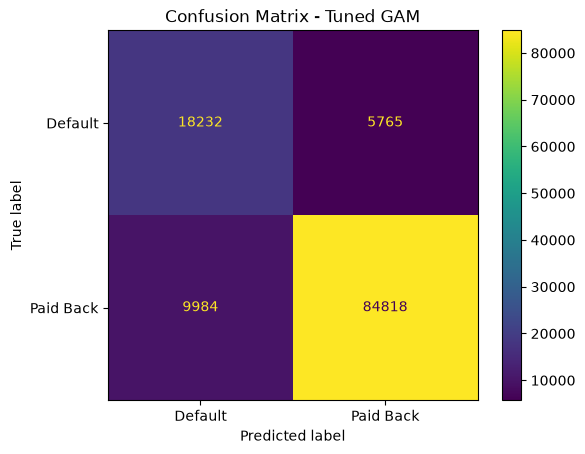

In [ ]:
cm = confusion_matrix(y_test, y_pred_gam)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Default", "Paid Back"]
)

disp.plot()
plt.title("Confusion Matrix - Tuned GAM")
plt.show()

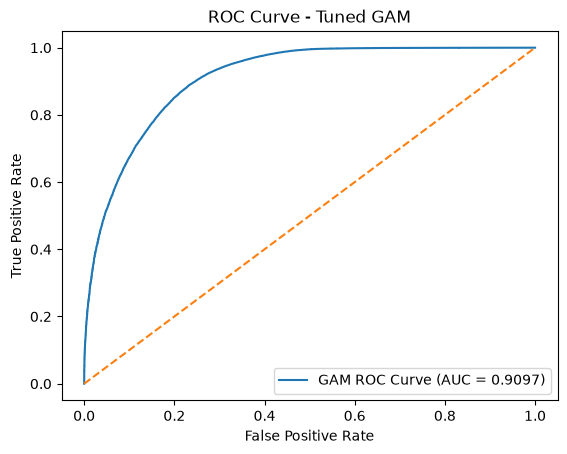

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gam)
auc_score = roc_auc_score(y_test, y_prob_gam)

plt.figure()
plt.plot(fpr, tpr, label=f"GAM ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned GAM")
plt.legend()
plt.show()

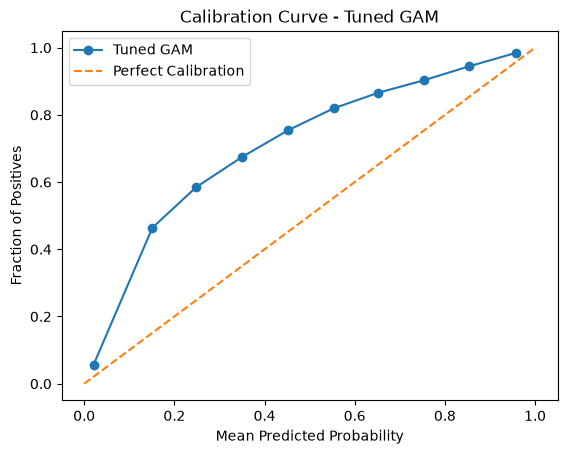

In [ ]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob_gam,
    n_bins=10
)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o", label="Tuned GAM")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve - Tuned GAM")
plt.legend()
plt.show()

In [ ]:
joblib.dump(
    final_gam,
    "../models/gam_model.pkl"
)

gam_best_parameters = pd.DataFrame({
    "Search Level": ["Level 1", "Level 2"],
    "Best Lambda": [best_lam_level1, best_lam],
    "Best Mean ROC-AUC": [
        level1_results_df["Mean ROC-AUC"].max(),
        level2_results_df["Mean ROC-AUC"].max()
    ],
    "Best Std ROC-AUC": [
        level1_results_df.loc[
            level1_results_df["Mean ROC-AUC"].idxmax(),
            "Std ROC-AUC"
        ],
        level2_results_df.loc[
            level2_results_df["Mean ROC-AUC"].idxmax(),
            "Std ROC-AUC"
        ]
    ]
})

gam_best_parameters.to_csv(
    "../results/gam_best_parameters.csv",
    index=False
)

gam_results_df.to_csv(
    "../results/gam_evaluation_results.csv",
    index=False
)

print("GAM model and results saved successfully.")

GAM model and results saved successfully.
